# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("Dataset\yulu_bike_sharing_dataset.csv")

# Inspect DataFrame Structure

With the DataFrame df loaded, we examine its basic structure. We display the shape (rows, columns), first few rows, last few rows, and a random sample to understand data layout. We also print column data types and non-null counts via df.info(). This includes memory usage and helps spot missing values.

In [3]:
# Show DataFrame dimensions and sample data
print(f"DataFrame shape (row, cols): {df.shape}")
print("\n")
print("Columns:", df.columns.tolist())
      

# Display first/last few rows
display(df.head())
display(df.tail())

# Display a random sample of 5 rows
display(df.sample(5, random_state=42))

DataFrame shape (row, cols): (10886, 12)


Columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
3133,2011-07-19 11:00:00,3,0,1,1,33.62,40.150,59,0.0000,29,98,127
5786,2012-01-16 06:00:00,1,1,0,1,4.10,6.820,54,6.0032,0,13,13
5224,2011-12-11 18:00:00,4,0,0,1,9.84,11.365,48,12.9980,12,151,163
8953,2012-08-15 10:00:00,3,0,1,2,29.52,34.090,62,12.9980,70,163,233
8054,2012-06-15 23:00:00,2,0,1,1,25.42,31.060,53,16.9979,46,176,222


In [4]:
# Show info: dtype, non-null counts, memory usage
df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1.7 MB


The df.info() output lists each column’s dtype, number of non-null entries, and memory usage. This quickly reveals if any column is completely null or of unexpected type (e.g. numeric data read as object/string).

## Summary Statistics

Next we compute descriptive statistics.<br>
We call df.describe() on numeric columns to get count, mean, std, min/25%/50%/75%/max values.<br>
For object (string/categorical) columns, describe() returns count, unique, most common value (top), and its frequency (freq).<br>
We also compute unique counts and value frequencies for categorical columns explicitly.

In [5]:
# Descriptive statistics for numeric columns
numeric_stats = df.describe()
display(numeric_stats)

# Descriptive stats for all columns (includes object dtypes, if any)
all_stats = df.describe(include='all')
display(all_stats)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


## Check Duplicates & Missing Data

In [6]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

# Show a sample of duplicate rows if any
if dup_count > 0:
    display(df[df.duplicated()])

# Count missing values per column
missing_counts = df.isnull().sum()
missing_percent = 100 * missing_counts / len(df)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
display(missing_table)

Number of duplicate rows: 0


,missing_count,missing_percent
datetime,0,0.0
season,0,0.0
holiday,0,0.0
workingday,0,0.0
weather,0,0.0
temp,0,0.0
atemp,0,0.0
humidity,0,0.0
windspeed,0,0.0
casual,0,0.0


# Handling Date and Time

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])
# df.info()

In [8]:
df['date_year'] = df['datetime'].dt.year
df['date_month'] = df['datetime'].dt.month
df['date_day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday # Monday: 0, Tuesday: 1, Wednesday: 2, Thursday: 3, Friday: 4, Saturday: 5, Sunday: 6
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
# df.sample(5)
display(df[['date_year', 'date_month', 'date_day', 'weekday', 'is_weekend', 'hour', 'workingday', 'holiday']].sample(5))

,date_year,date_month,date_day,weekday,is_weekend,hour,workingday,holiday
10234,2012,11,11,6,1,20,0,0
2085,2011,5,13,4,0,19,1,0
5523,2012,1,5,3,0,6,1,0
10819,2012,12,17,0,0,5,1,0
6053,2012,2,8,2,0,11,1,0


In [9]:
# Drop Datetime Column
df.drop('datetime', axis=1, inplace=True)

In [10]:
df.drop(['casual', 'registered'], axis=1, inplace=True)

In [11]:
# Labeling categorical columns textually
# We may convert them to numbers later
df_labeled = df.copy()
season_map = {1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'}
df_labeled['season'] = df_labeled['season'].map(season_map)

binary_map = {0: 'No', 1: 'Yes'}
df_labeled['holiday'] = df_labeled['holiday'].map(binary_map)

df_labeled['workingday'] = df_labeled['workingday'].map(binary_map)

df_labeled['is_weekend'] = df_labeled['is_weekend'].map(binary_map)

month_map = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
df_labeled['date_month'] = df_labeled['date_month'].map(month_map)

weekday_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
df_labeled['weekday'] = df_labeled['weekday'].map(weekday_map)

df_labeled.sample(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,date_year,date_month,date_day,hour,weekday,is_weekend
8376,fall,No,Yes,1,30.34,34.850,66,8.9981,331,2012,July,10,9,Tuesday,No
6835,summer,No,Yes,1,15.58,19.695,46,0.0000,3,2012,April,3,3,Tuesday,No
1246,spring,No,Yes,2,18.04,21.970,54,15.0013,237,2011,March,16,18,Wednesday,No
6363,spring,No,Yes,1,12.30,16.665,81,0.0000,314,2012,March,2,9,Friday,No
9307,fall,No,Yes,1,19.68,23.485,72,7.0015,9,2012,September,11,4,Tuesday,No


# Exploratory Data Analysis (EDA)
EDA is the process of understanding and analyzing data before building machine learning models.

**Types Of Data**<br>
Before performing EDA, identify the types of data.<br>

**A. Numerical Date:-** Date represented by numbers.<br>
`temp`: temperature in Celsius<br>
`atemp`: feeling temperature in Celsius<br>
`humidity`: humidity<br>
`windspeed`: wind speed<br>
`casual`: count of casual users<br>
`registered`: count of registered users<br>
`count`: count of total rental bikes including both casual and registered<br>

**B. Categorical Date:-** Date represented by category.<br>
`season`: season (1: spring, 2: summer, 3: fall, 4: winter)<br>
`holiday`: whether day is a holiday or not (0: No, 1: Yes)<br>
`workingday`: if day is neither weekend nor holiday is 1, otherwise is 0<br>
`weather`: 1: Clear, Few clouds, partly cloudy, partly cloudy<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog<br>

**Note:-** The analysis method depends on whether the column is numerical or categorical.<br>

## Univariate Analysis For Numerical Data
**Goal:-**<br>
- Understand data distribution.
- Find central tendency.
- Detect outliers.
- Check skewness.

### Boxplot of Count

<Axes: xlabel='count'>

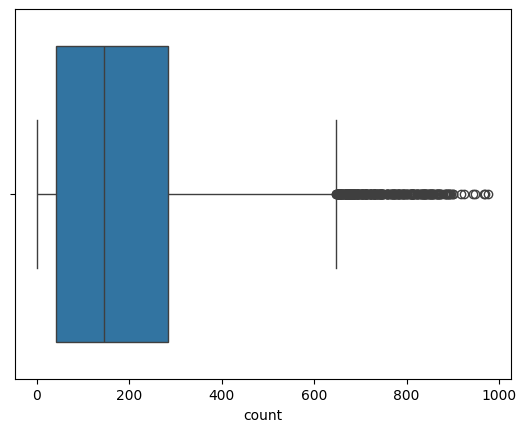

In [12]:
sns.boxplot(x=df_labeled['count'])

**Observartion:-**<br>
- Large number of outliers present.
- Majority of data lies between lower count values.

### Histogram of Count

<Axes: xlabel='count', ylabel='Count'>

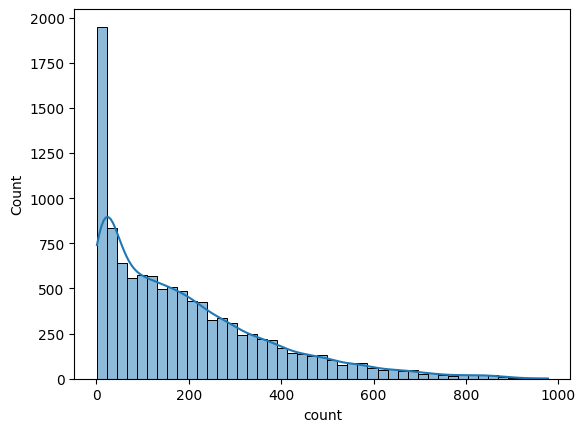

In [13]:
sns.histplot(df_labeled['count'], kde=True)

**Observartion:-**<br>
- Count distribution is right skewed.
- Data is not normally distributed.

## Bivariate Analysis And Multivariate Analysis
**Types Of Variable Combination**<br>
When analyzing two variables, there are three possible combinations:-<br>
&nbsp;&nbsp;&nbsp;**Variable1&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Variable2**<br>
&nbsp;&nbsp;&nbsp;Numerical&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Numerical<br>
&nbsp;&nbsp;&nbsp;Numerical&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Catergorical<br>
&nbsp;&nbsp;Catergorical&nbsp;&nbsp;&nbsp;Catergorical<br>

### Scatter Plot (Numerical Features vs Count)
**Goal:-**<br>
- Find relationships between variables.
- Detect trends.
- Detect correlation.
- Identify outliers.

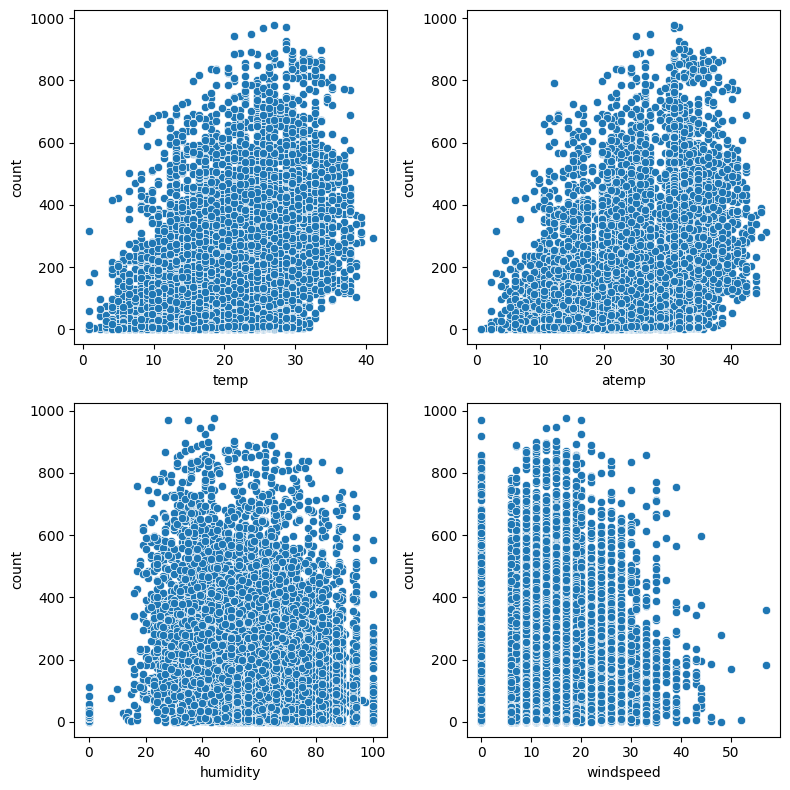

In [14]:
num_cols = [
    'temp',
    'atemp',
    'humidity',
    'windspeed',
    'casual',
    'registered',
    'count'
]

plt.figure(figsize=(8,8))

for idx, col in enumerate(num_cols[:4], start=1):
    plt.subplot(2, 2, idx)
    sns.scatterplot(data=df_labeled, x=col, y=num_cols[-1])
    plt.xlabel(col)
    plt.ylabel(num_cols[-1])
plt.tight_layout()
plt.show()

<Axes: xlabel='atemp', ylabel='count'>

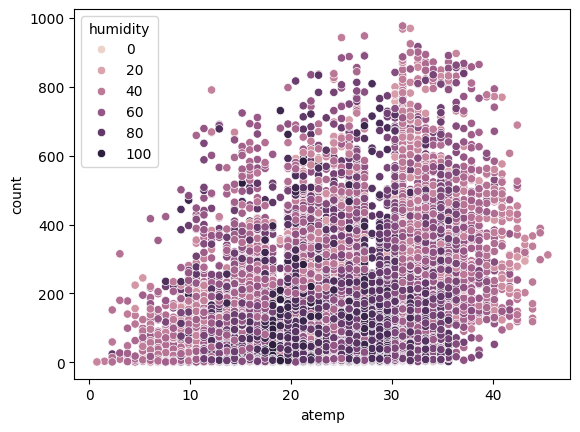

In [15]:
sns.scatterplot(
    data=df_labeled,
    x='atemp',
    y='count',
    hue='humidity'
)

### Boxplot (Categorical Features vs Count)
**Goal:-** Analyze impact of categories on bike demand.

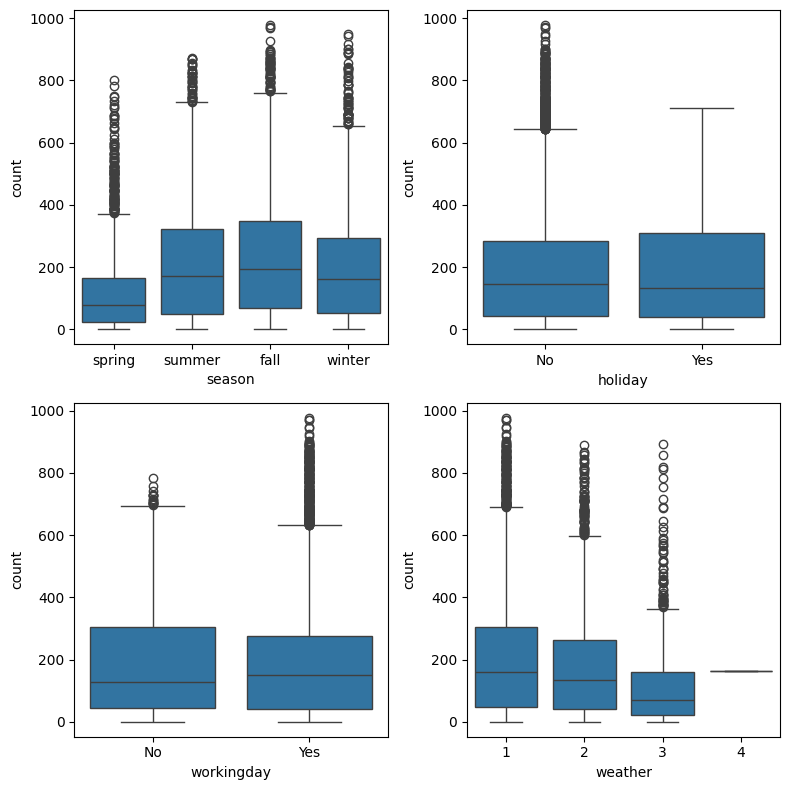

In [16]:
cat_cols = [
    'season',
    'holiday',
    'workingday',
    'weather'
]

plt.figure(figsize=(8,8))

for idx, col in enumerate(cat_cols[:4], start=1):
    plt.subplot(2, 2, idx)
    sns.boxplot(data=df_labeled, x=col, y='count')
    plt.xlabel(col)
    plt.ylabel('count')
plt.tight_layout()
plt.show()

### Correlation Heatmap

<Axes: >

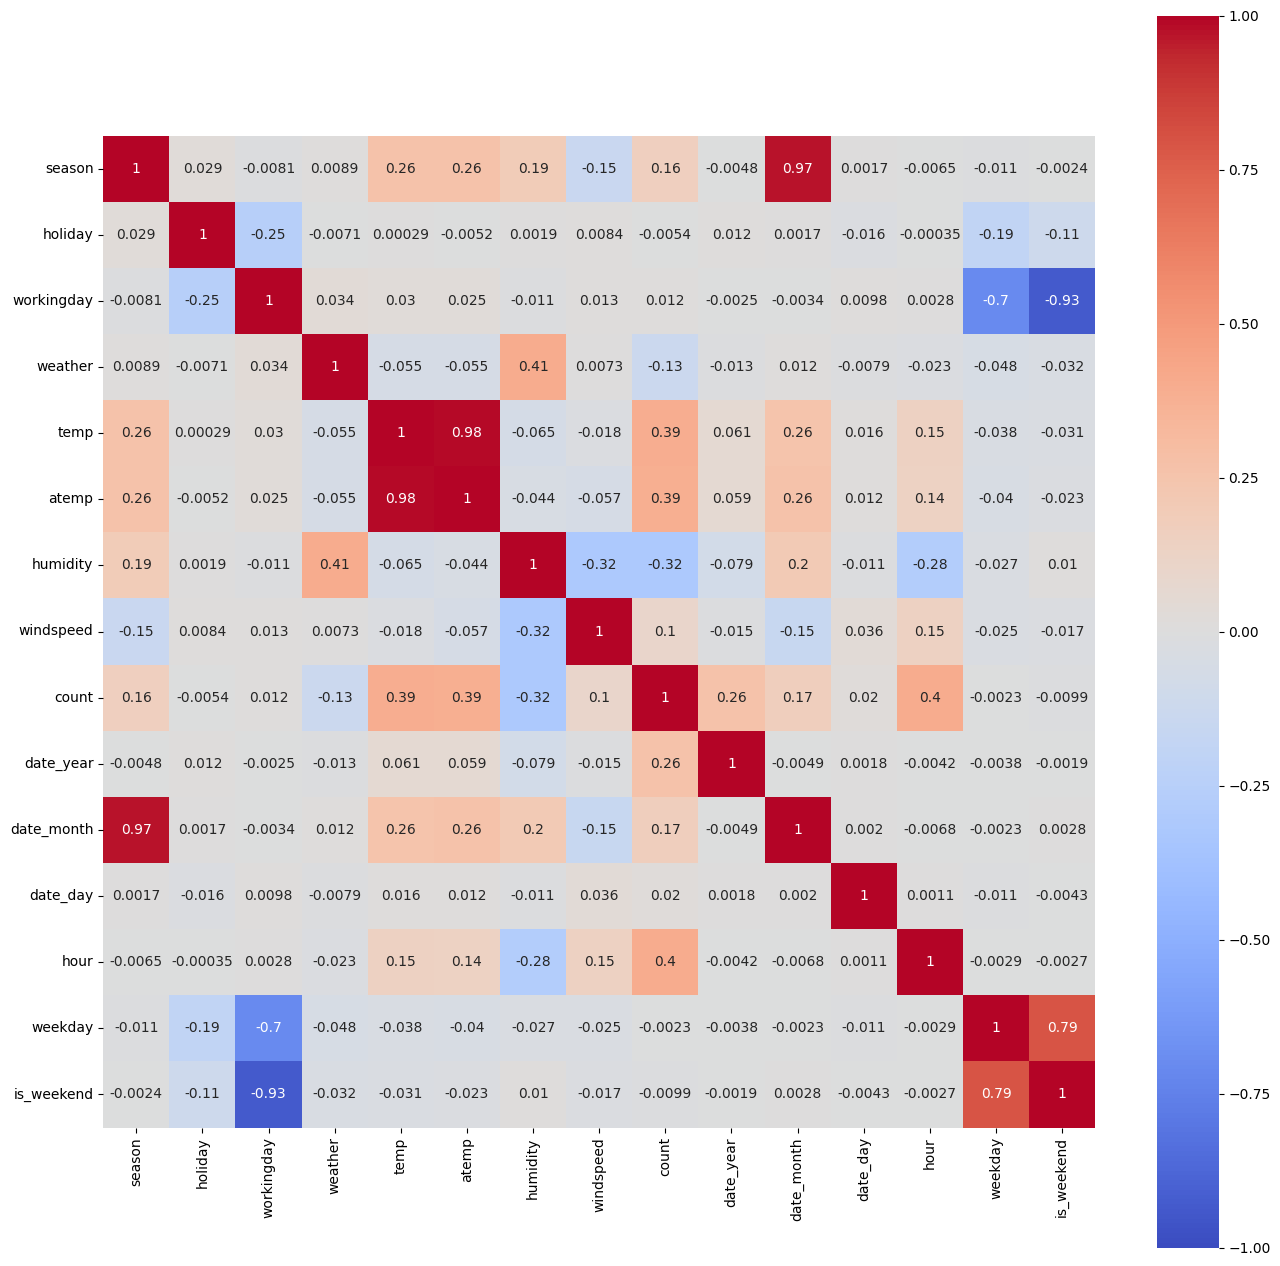

In [17]:
plt.figure(figsize=(16,16))
sns.heatmap(data=df.corr('pearson'), vmin=-1, vmax=1, cmap='coolwarm', annot=True, square=True)

**Strong Positive Correlations**<br>
`temp` ↔ `atemp` = `0.98`<br>
- Almost identical information.<br>
- Potential multicollinearity.<br>
`season` ↔ `date_month` = `0.97`<br>
- Seasons are determined by months, so this is expected.<br>
`weekday` ↔ `is_weekend` = `0.79`<br>
- Strong relationship between day of week and weekend status.<br>

**Moderate Positive Correlations with Target (count)**<br>
`hour` ↔ `count` = `0.40`<br>
`temp` ↔ `count` = `0.39`<br>
`atemp` ↔ `count` = `0.39`<br>
- These variables appear useful for prediction.<br>

**Moderate Negative Correlations with Target (count)**<br>
`humidity` ↔ `count` = `-0.32`<br>
- Higher humidity tends to reduce rentals.<br>
`weather` ↔ `count` = `-0.13`<br>
- Worse weather generally leads to fewer rentals.<br>

**Strong Negative Correlations**<br>
`workingday` ↔ `is_weekend` = `-0.93`<br>
- Expected since weekends are generally not working days.<br>
`workingday` ↔ `weekday` = `-0.70`<br>
- Strong inverse relationship.<br>

# Time-Based Analysis

### Barplot (Categorical Features vs count)

C:\Users\ooo\AppData\Local\Temp\ipykernel_24456\1631580822.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_labeled, x='date_year', y='count', palette='Set2')


<Axes: xlabel='date_year', ylabel='count'>

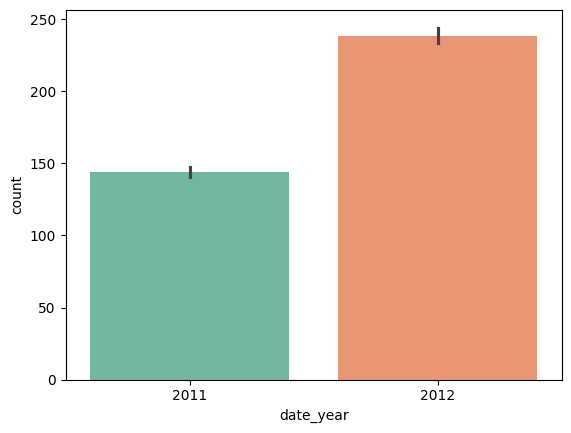

In [30]:
plt.figure(figsize=(16,5))
sns.barplot(data=df_labeled, x='date_year', y='count', palette='Set2')

### Count Plot
It show the frequency of each category.

season
winter    2734
summer    2733
fall      2733
spring    2686
Name: count, dtype: int64


<Axes: xlabel='season', ylabel='count'>

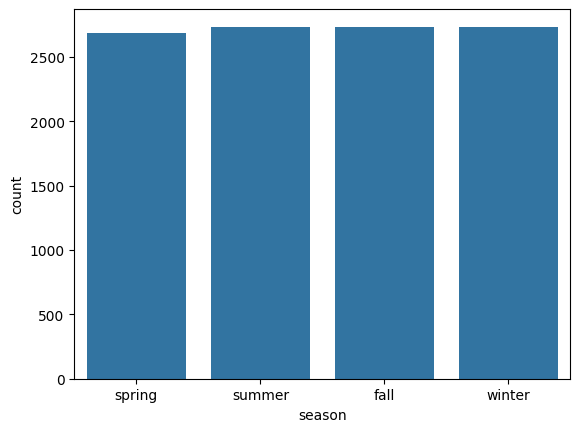

In [12]:
# Lets see for which season, how many people rented bikes.
print(df['season'].value_counts())
sns.countplot(x=df['season'])

So, in winter, summer and fall the count is almost same but in spring count decreased by very small amount.

## Outlier Detection and Treatment

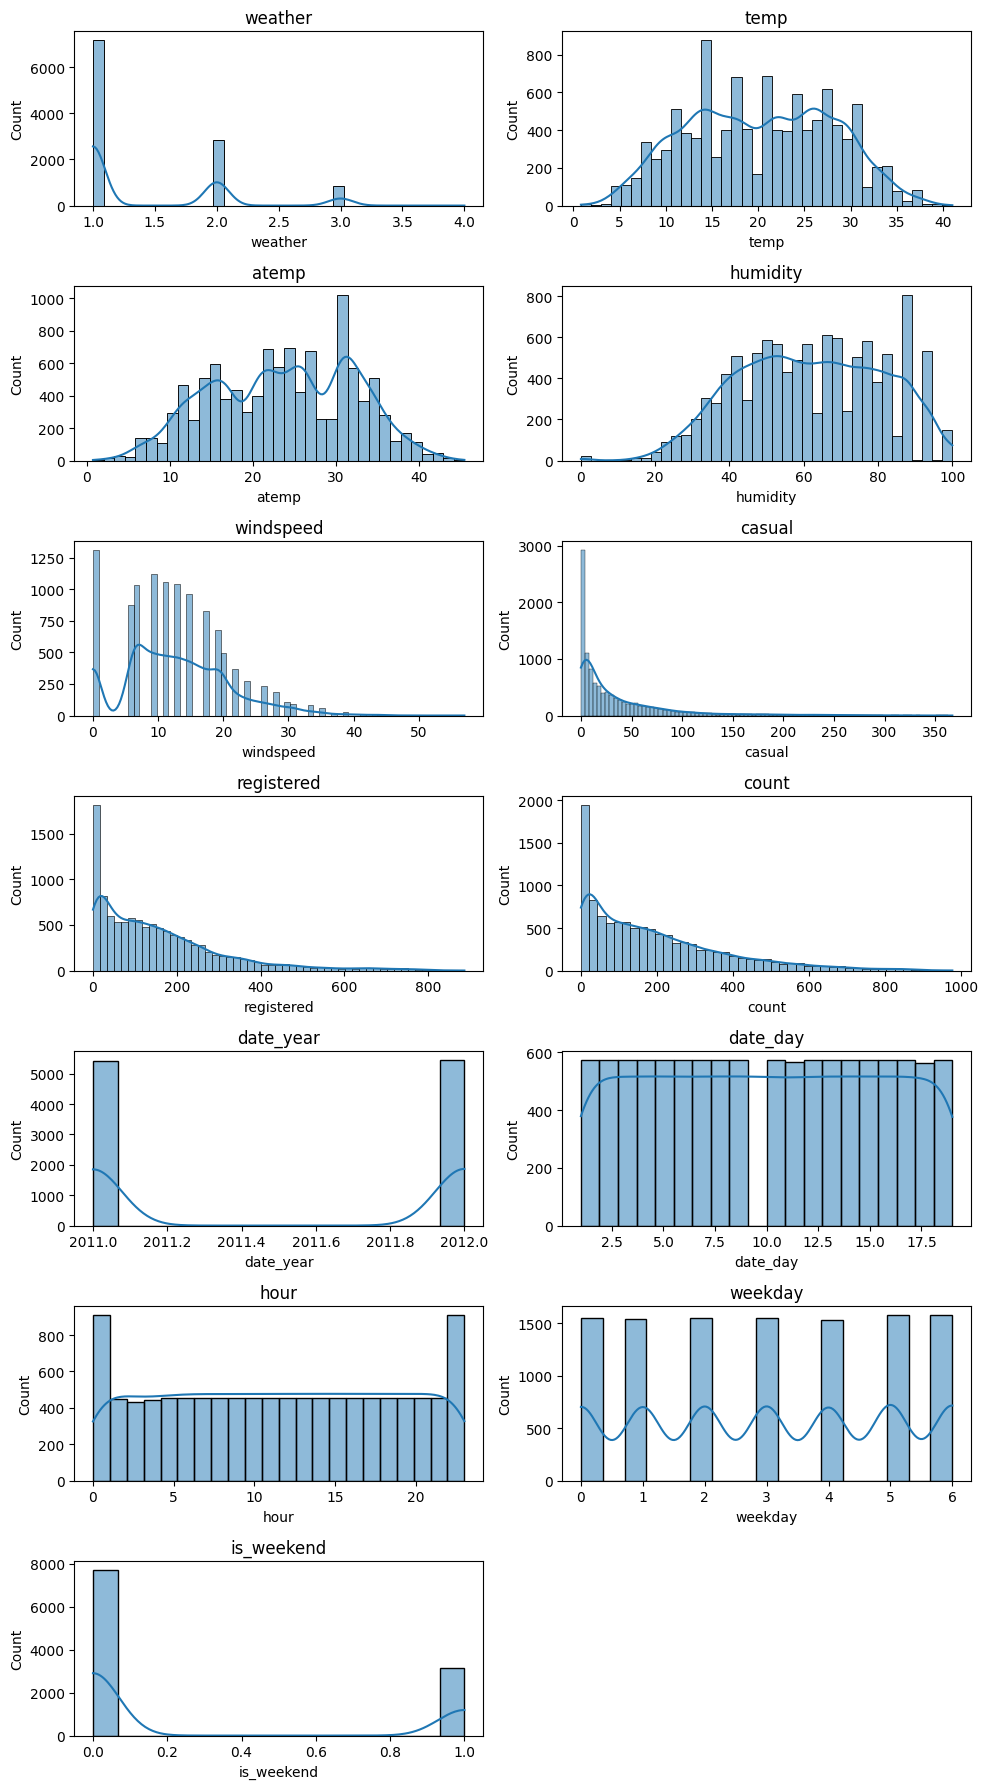

In [11]:
plt.figure(figsize=(10,18))
numeric_cols = df.select_dtypes(include=[np.number]).columns
no_r = len(numeric_cols)//2 # // : returns int, / : returns float
for idx, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols)+1)//2, 2, idx) #(rows, cols, position)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

1. Categorical Variables<br>
`season`, `holiday`, `workingday`, `weather`, `date_year`, `date_month`, `date_day`, `hour`
- These are categorical features.<br>
- Do not perform outlier detection on these.<br>
2. Temperature(`temp`)<br>
- Roughly bell-shaped.
- No suspicious extreme values.
- Range looks reasonable (~0-41°C).
- No treatment required.
3. Atmospheric Temperature (`atemp`)
- Similar to `temp`.
- Distribution is reasonable.
- No treatment required
4. Humidity (`humidity`)
- Values mostly between 20-100.
- Humidity naturally ranges from 0-100%.
- No treatment required.
5. Windspeed (`windspeed`)
- Distribution is strongly right-skewed.
- May require treatment

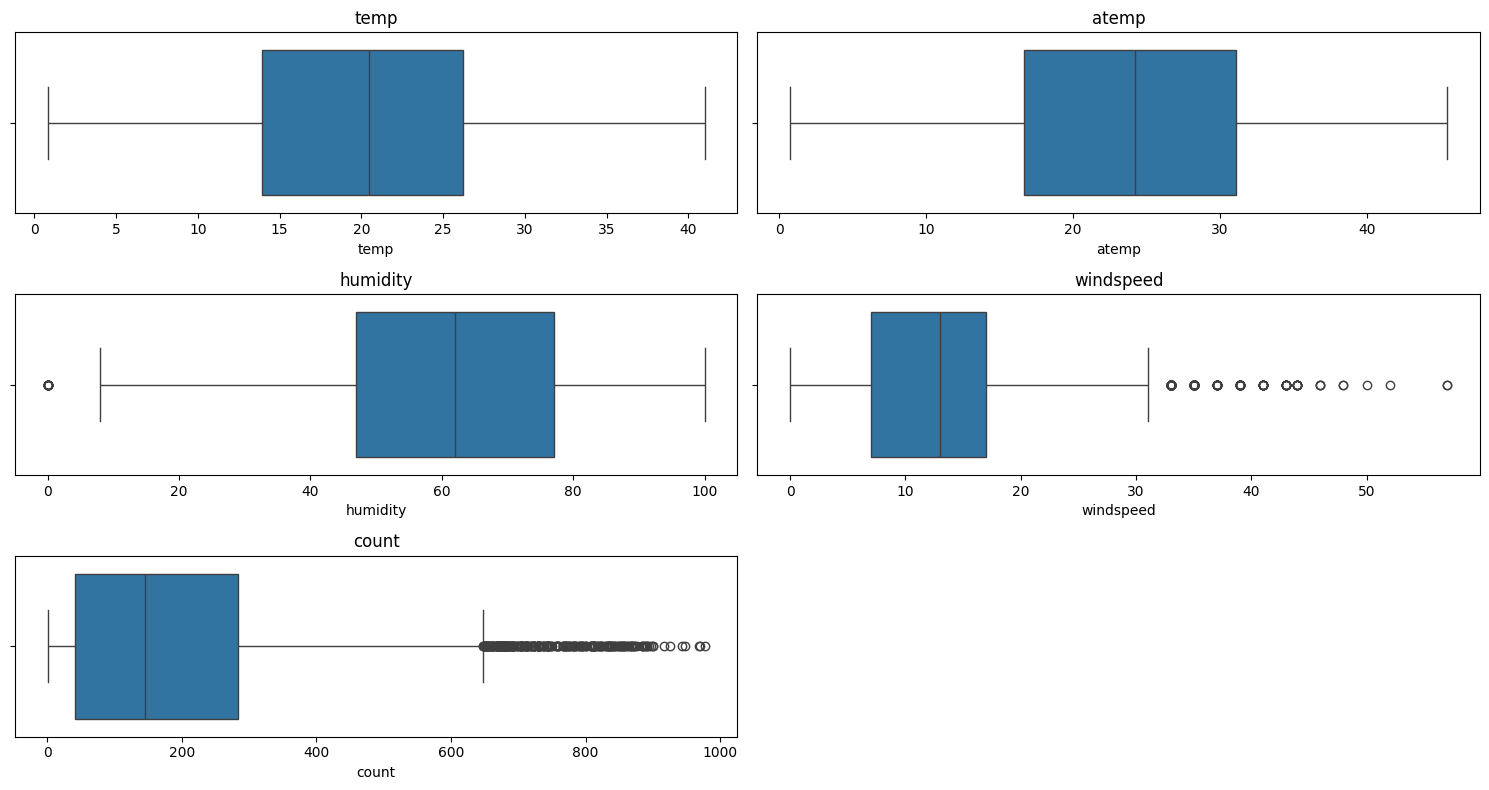

In [16]:
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']

plt.figure(figsize=(15,8))

for idx, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 2, idx)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Since the detected extreme values correspond to valid weather conditions and genuine bike rental demand observations, no outlier removal is needed to performed.

In [18]:
"""
# Compute IQR
Q1 = df['windspeed'].quantile(0.25)
Q3 = df['windspeed'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR
print("upper_limit:", upper_limit)
print("lower_limit:", lower_limit)
# Capping
df['windspeed'] = np.where(
    df['windspeed'] > upper_limit,
    upper_limit,
    np.where(
        df['windspeed'] < lower_limit,
        lower_limit,
        df['windspeed']
    )
)
display(df['windspeed'].describe())
sns.boxplot(x=df['windspeed'])
"""

'\n# Compute IQR\nQ1 = df[\'windspeed\'].quantile(0.25)\nQ3 = df[\'windspeed\'].quantile(0.75)\nIQR = Q3 - Q1\nupper_limit = Q3 + 1.5*IQR\nlower_limit = Q1 - 1.5*IQR\nprint("upper_limit:", upper_limit)\nprint("lower_limit:", lower_limit)\n# Capping\ndf[\'windspeed\'] = np.where(\n    df[\'windspeed\'] > upper_limit,\n    upper_limit,\n    np.where(\n        df[\'windspeed\'] < lower_limit,\n        lower_limit,\n        df[\'windspeed\']\n    )\n)\ndisplay(df[\'windspeed\'].describe())\nsns.boxplot(x=df[\'windspeed\'])\n'

## Encoding Categorical Variables

In [20]:
df.sample(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date_year,date_month,date_day,hour,weekday,is_weekend
4549,winter,No,Yes,1,19.68,23.485,51,11.0014,26,161,187,2011,November,2,15,2,0
3465,fall,No,No,2,27.06,29.545,89,12.9980,4,20,24,2011,August,14,7,6,1
4689,winter,No,Yes,1,18.86,22.725,63,8.9981,21,126,147,2011,November,8,11,1,0
5503,spring,No,Yes,1,2.46,5.305,45,0.0000,7,57,64,2012,January,4,10,2,0
5776,spring,No,No,1,6.56,9.090,37,7.0015,10,85,95,2012,January,15,20,6,1


Since: count = casual + registered<br>
these columns must not be used as features.

In [22]:
print(df['season'].value_counts())
print(df['weather'].value_counts())
print(df['date_year'].value_counts())
print(df['date_month'].value_counts())
print(df['weekday'].value_counts())
print(df['is_weekend'].value_counts())
print(df['hour'].value_counts())
print(df['workingday'].value_counts())
print(df['holiday'].value_counts())

season
winter    2734
summer    2733
fall      2733
spring    2686
Name: count, dtype: int64
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
date_year
2012    5464
2011    5422
Name: count, dtype: int64
date_month
May          912
June         912
July         912
August       912
December     912
October      911
November     911
April        909
September    909
February     901
March        901
January      884
Name: count, dtype: int64
weekday
5    1584
6    1579
3    1553
0    1551
2    1551
1    1539
4    1529
Name: count, dtype: int64
is_weekend
0    7723
1    3163
Name: count, dtype: int64
hour
12    456
13    456
22    456
21    456
20    456
19    456
18    456
17    456
16    456
15    456
14    456
23    456
11    455
10    455
9     455
8     455
7     455
6     455
0     455
1     454
5     452
2     448
4     442
3     433
Name: count, dtype: int64
workingday
Yes    7412
No     3474
Name: count, dtype: int64
holiday
No     10575
Yes      311
Nam

1. Season (`season`)<br>
`1 = Spring`<br>
`2 = Summer`<br>
`3 = Fall`<br>
`4 = Winter`<br>
Problem:<br>
If we directly use: `1, 2, 3, 4`<br>
ML algorithm may assume: `4 > 3 > 2 > 1`<br>
Solution: One-Hot Encoding
2. Weather(`weather`)<br>
`1 = Clear, Few clouds, partly cloudy, partly cloudy`<br>
`2 = Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist`<br>
`3 = Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds`<br>
`4 = Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog`<br>
Solution: One-Hot Encoding
3. Year (`date_year`)<br>
Since the dataset contains only<br>
`2012`<br>
`2011`<br>
we can convert it to:<br>
`2012 -> 0`<br>
`2011 -> 1`<br>
4. Month (`date_month`)<br>
`1 = January`<br>
`2 = February`<br>
`3 = March`<br>
`4 = April`<br>
`5 = May`<br>
`6 = June`<br>
`7 = July`<br>
`8 = August`<br>
`9 = September`<br>
`10 = October`<br>
`11 = November`<br>
`12 = December`<br>
Solution: One-Hot Encoding
5. Weekday (`weekday`)<br>
`0 = Monday`<br>
`1 = Tuesday`<br>
`2 = Wednesday`<br>
`3 = Thursday`<br>
`4 = Friday`<br>
`5 = Saturday`<br>
`6 = Sunday`<br>
Solution: One-Hot Encoding<br>
6. Is Weekend (`is_weekend`)<br>
`0`<br>
`1`<br>
- Binary column.
- No encoding needed.
7. Hour (`hour`)<br>
Solution: <br>
8. Working day (`working_day`)<br>
`0`<br>
`1`<br>
- Binary column.
- No encoding needed.
9. Holiday (`holiday`)<br>
`0`<br>
`1`<br>
- Binary column.
- No encoding needed.

### One-Hot Encoding

In [17]:
categorical_cols = ['season', 'weather', 'date_month', 'weekday']
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
display(df_encoded.sample(5))
print(df_encoded.iloc[0])
df_encoded.columns.to_list()

,holiday,workingday,temp,atemp,humidity,windspeed,count,date_year,date_day,hour,...,date_month_May,date_month_November,date_month_October,date_month_September,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
5396,No,No,9.02,11.365,75,12.9980,49,2011,18,22,...,0,0,0,0,0,0,0,0,0,1
7525,No,No,22.96,26.515,68,8.9981,274,2012,12,22,...,1,0,0,0,0,0,0,0,1,0
7288,No,Yes,18.86,22.725,88,7.0015,24,2012,3,1,...,1,0,0,0,0,0,1,0,0,0
8827,No,Yes,28.70,33.335,84,19.0012,7,2012,10,4,...,0,0,0,0,0,0,0,1,0,0
1111,No,Yes,13.94,16.665,0,8.9981,34,2011,10,22,...,0,0,0,0,0,0,1,0,0,0


holiday                     No
workingday                  No
temp                      9.84
atemp                   14.395
humidity                    81
windspeed                  0.0
count                       16
date_year                 2011
date_day                     1
hour                         0
is_weekend                   1
season_spring                1
season_summer                0
season_winter                0
weather_2                    0
weather_3                    0
weather_4                    0
date_month_August            0
date_month_December          0
date_month_February          0
date_month_January           1
date_month_July              0
date_month_June              0
date_month_March             0
date_month_May               0
date_month_November          0
date_month_October           0
date_month_September         0
weekday_1                    0
weekday_2                    0
weekday_3                    0
weekday_4                    0
weekday_

['holiday',
 'workingday',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'count',
 'date_year',
 'date_day',
 'hour',
 'is_weekend',
 'season_spring',
 'season_summer',
 'season_winter',
 'weather_2',
 'weather_3',
 'weather_4',
 'date_month_August',
 'date_month_December',
 'date_month_February',
 'date_month_January',
 'date_month_July',
 'date_month_June',
 'date_month_March',
 'date_month_May',
 'date_month_November',
 'date_month_October',
 'date_month_September',
 'weekday_1',
 'weekday_2',
 'weekday_3',
 'weekday_4',
 'weekday_5',
 'weekday_6']

In [18]:
# df_encoded['date_year'] = df['date_year'] - 2011
df_encoded['date_year'] = df['date_year'].map({
    2011: 0,
    2012: 1
})
df_encoded['date_year'].value_counts()

date_year
1    5464
0    5422
Name: count, dtype: int64

## Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df_encoded.drop('count', axis=1)
y = df_encoded['count']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

### Standardization

Note: Binary columns does not require feature scaling.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
display(df_encoded.describe())
cols = []
for col in X.columns:
    if int(X[col].mean()) != 0:
        
        cols.append(col)
print(cols)

,temp,atemp,humidity,windspeed,count,date_year,date_day,hour,is_weekend,season_spring,...,date_month_May,date_month_November,date_month_October,date_month_September,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,...,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.703540,191.574132,0.501929,9.992559,11.541613,0.290557,0.246739,...,0.083777,0.083685,0.083685,0.083502,0.141374,0.142477,0.142660,0.140456,0.145508,0.145049
std,7.79159,8.474601,19.245033,7.882794,181.144454,0.500019,5.476608,6.915838,0.454040,0.431133,...,0.277066,0.276928,0.276928,0.276652,0.348423,0.349554,0.349742,0.347475,0.352628,0.352166
min,0.82000,0.760000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.94000,16.665000,47.000000,7.001500,42.000000,0.000000,5.000000,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.50000,24.240000,62.000000,12.998000,145.000000,1.000000,10.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,26.24000,31.060000,77.000000,16.997900,284.000000,1.000000,15.000000,18.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,41.00000,45.455000,100.000000,31.992500,977.000000,1.000000,19.000000,23.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


TypeError: Could not convert ... to numeric

In [ ]:
scaler = StandardScaler()
# scaler.fit(X_train[cols])

In [ ]:
# X_train[cols] = scaler.transform(X_train[cols])
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [ ]:
X_train.describe()

## Train Baseline Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))